<a href="https://colab.research.google.com/github/NugrahM2409/Pengenalan-Pola/blob/main/Praktikum3_Pengenalan_Pola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Inisialisasi Library

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

##Load Dataset Flags

In [54]:

# tambahkan nama kolom sesuai dokumentasi UCI
columns = [
    "name","landmass","zone","area","population",
    "language","religion","bars","stripes","colours",
    "red","green","blue","gold","white","black","orange",
    "mainhue","circles","crosses","saltires","quarters",
    "sunstars","crescent","triangle","icon","animate",
    "text","topleft","botright"
]

flags = pd.read_csv("flag.data", names=columns)

flags.head()

,name,landmass,zone,area,population,language,religion,bars,stripes,colours,...,saltires,quarters,sunstars,crescent,triangle,icon,animate,text,topleft,botright
0,Afghanistan,5,1,648,16,10,2,0,3,5,...,0,0,1,0,0,1,0,0,black,green
1,Albania,3,1,29,3,6,6,0,0,3,...,0,0,1,0,0,0,1,0,red,red
2,Algeria,4,1,2388,20,8,2,2,0,3,...,0,0,1,1,0,0,0,0,green,white
3,American-Samoa,6,3,0,0,1,1,0,0,5,...,0,0,0,0,1,1,1,0,blue,red
4,Andorra,3,1,0,0,6,0,3,0,3,...,0,0,0,0,0,0,0,0,blue,red


##Menghapus Atribut Non Numerik

In [55]:
flags = flags.drop(["name","mainhue","topleft","botright"], axis=1)

flags.head()

,landmass,zone,area,population,language,religion,bars,stripes,colours,red,...,circles,crosses,saltires,quarters,sunstars,crescent,triangle,icon,animate,text
0,5,1,648,16,10,2,0,3,5,1,...,0,0,0,0,1,0,0,1,0,0
1,3,1,29,3,6,6,0,0,3,1,...,0,0,0,0,1,0,0,0,1,0
2,4,1,2388,20,8,2,2,0,3,1,...,0,0,0,0,1,1,0,0,0,0
3,6,3,0,0,1,1,0,0,5,1,...,0,0,0,0,0,0,1,1,1,0
4,3,1,0,0,6,0,3,0,3,1,...,0,0,0,0,0,0,0,0,0,0


##Menentukan variabel target yaitu Landmass
###1= North America, 2= South America, 3= Europe, 4= Africa, 5= Asia, 6= Oceania

In [56]:
# variabel bebas
x = flags.drop(["landmass"], axis=1)
x.head()


,zone,area,population,language,religion,bars,stripes,colours,red,green,...,circles,crosses,saltires,quarters,sunstars,crescent,triangle,icon,animate,text
0,1,648,16,10,2,0,3,5,1,1,...,0,0,0,0,1,0,0,1,0,0
1,1,29,3,6,6,0,0,3,1,0,...,0,0,0,0,1,0,0,0,1,0
2,1,2388,20,8,2,2,0,3,1,1,...,0,0,0,0,1,1,0,0,0,0
3,3,0,0,1,1,0,0,5,1,0,...,0,0,0,0,0,0,1,1,1,0
4,1,0,0,6,0,3,0,3,1,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
# variabel tidak bebas
y = flags["landmass"]
y.head()

,landmass
0,5
1,3
2,4
3,6
4,3


##Klasifikasi dengan Naive Bayes

In [58]:
#membagi data menjadi data training dan data testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

#menggunakan model Gaussian Naive Bayes
flags_model = GaussianNB()

#Melatih Model
NB_train = flags_model.fit(x_train, y_train)

y_pred = NB_train.predict(x_test)

np.array(y_pred)
np.array(y_test)

NB_train.predict_proba(x_test)

array([[0.00000000e+000, 5.43405656e-012, 9.99999548e-001,
        4.28351304e-007, 1.01652035e-008, 1.39107769e-008],
       [8.85645113e-001, 3.15266472e-037, 8.78846141e-002,
        1.41247100e-002, 0.00000000e+000, 1.23455626e-002],
       [0.00000000e+000, 2.34398250e-007, 8.09392249e-044,
        9.98402279e-001, 1.55034013e-003, 4.71461178e-005],
       [5.60382382e-001, 4.37293342e-001, 1.96209548e-036,
        2.32417163e-003, 0.00000000e+000, 1.04373913e-007],
       [1.87393859e-159, 1.07358750e-012, 6.65726161e-042,
        1.00000000e+000, 2.44771113e-040, 2.14312218e-015],
       [0.00000000e+000, 3.72633524e-009, 3.11226280e-068,
        3.79928400e-005, 9.99962003e-001, 1.52199202e-033],
       [0.00000000e+000, 5.24645049e-013, 0.00000000e+000,
        2.26033984e-103, 7.18191966e-028, 1.00000000e+000],
       [3.21246588e-008, 1.12804584e-008, 9.99976496e-001,
        2.34706638e-009, 0.00000000e+000, 2.34579986e-005],
       [0.00000000e+000, 4.30324461e-011, 2.8398

##Performa model dengan Confusion Matrix

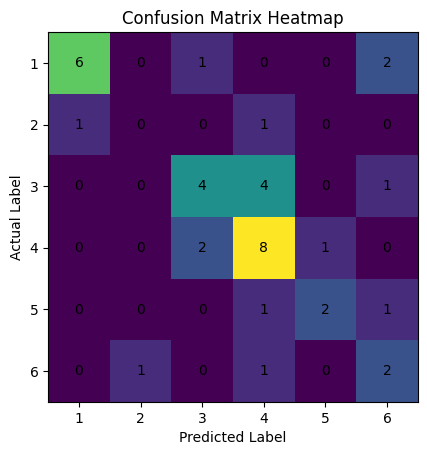

              precision    recall  f1-score   support

           1       0.86      0.67      0.75         9
           2       0.00      0.00      0.00         2
           3       0.57      0.44      0.50         9
           4       0.53      0.73      0.62        11
           5       0.67      0.50      0.57         4
           6       0.33      0.50      0.40         4

    accuracy                           0.56        39
   macro avg       0.49      0.47      0.47        39
weighted avg       0.58      0.56      0.56        39



In [59]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure()
plt.imshow(cm)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")

plt.show()

print(classification_report(y_test, y_pred))